# 1. Loading modules

In [111]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import itertools
import networkx as nx
from itertools import combinations
from scipy.stats import gaussian_kde

# 2. Loading data

In [112]:
df = pd.read_csv('/Users/seohyori/desktop/coffee_survey.csv')
print(df.shape) 
print(df.head())

(4042, 57)
  submission_id              age cups where_drink  \
0        gMR29l  18-24 years old  NaN         NaN   
1        BkPN0e  25-34 years old  NaN         NaN   
2        W5G8jj  25-34 years old  NaN         NaN   
3        4xWgGr  35-44 years old  NaN         NaN   
4        QD27Q8  25-34 years old  NaN         NaN   

                                          brew brew_other purchase  \
0                                          NaN        NaN      NaN   
1  Pod/capsule machine (e.g. Keurig/Nespresso)        NaN      NaN   
2                          Bean-to-cup machine        NaN      NaN   
3     Coffee brewing machine (e.g. Mr. Coffee)        NaN      NaN   
4                                    Pour over        NaN      NaN   

  purchase_other             favorite favorite_specify  \
0            NaN  Regular drip coffee              NaN   
1            NaN          Iced coffee              NaN   
2            NaN  Regular drip coffee              NaN   
3            NaN 

# 3. Data pre-processing

## 3.1 Drop missing values- will be done in the first part of each section

## 3.2 Drop irrelevant columns

In [113]:
# Columns to keep for further analysis
columns_to_keep = ['age', 'favorite', 'style', 'strength', 'roast_level', 'caffeine', 'most_willing']

# A new DataFrame with only the columns we want to keep
df_cleaned = df[columns_to_keep]

print(df_cleaned.head())

               age             favorite    style strength roast_level  \
0  18-24 years old  Regular drip coffee  Complex      NaN         NaN   
1  25-34 years old          Iced coffee    Light      NaN         NaN   
2  25-34 years old  Regular drip coffee  Complex      NaN         NaN   
3  35-44 years old          Iced coffee  Complex      NaN         NaN   
4  25-34 years old                Latte    Sweet      NaN         NaN   

  caffeine most_willing  
0      NaN          NaN  
1      NaN          NaN  
2      NaN          NaN  
3      NaN          NaN  
4      NaN          NaN  


# 4. Coffee Prefences Trend by generations

## 4.1 Define Generation Groups based on 'age' column

In [114]:
# Categorize generation based on age
def categorize_generation(age):
    if isinstance(age, str):  # Ensure we are working with a string
        if '<18 years old' in age or '18-24 years old' in age:
            return 'Gen Z'
        elif '25-34 years old' in age or '35-44 years old' in age:
            return 'Millennials'
        else:
            return 'Others'

In [115]:
# Create a copy of the DataFrame before assigning
df_cleaned_age = df_cleaned.copy()

# Remove rows with NaN or empty values in the 'age' column
df_cleaned_age = df_cleaned_age.dropna(subset=['age'])

# Create the 'generation' column 
df_cleaned_age.loc[:, 'generation'] = df_cleaned_age['age'].apply(categorize_generation)

# Verify the new column 'generation'
print(df_cleaned_age[['age', 'generation']].head(100))

                 age   generation
0    18-24 years old        Gen Z
1    25-34 years old  Millennials
2    25-34 years old  Millennials
3    35-44 years old  Millennials
4    25-34 years old  Millennials
5    55-64 years old       Others
6    18-24 years old        Gen Z
8    25-34 years old  Millennials
10   18-24 years old        Gen Z
13     <18 years old        Gen Z
14   25-34 years old  Millennials
15     <18 years old        Gen Z
16     >65 years old       Others
17   25-34 years old  Millennials
18   25-34 years old  Millennials
19   18-24 years old        Gen Z
20   18-24 years old        Gen Z
21   18-24 years old        Gen Z
22   35-44 years old  Millennials
23   25-34 years old  Millennials
24   45-54 years old       Others
25   18-24 years old        Gen Z
26   35-44 years old  Millennials
28   25-34 years old  Millennials
29   18-24 years old        Gen Z
30   25-34 years old  Millennials
31   18-24 years old        Gen Z
32   18-24 years old        Gen Z
33     <18 yea

## 4.2 Visualizations

### 4.2.1 Brewing Preferences 

### Bar Chart

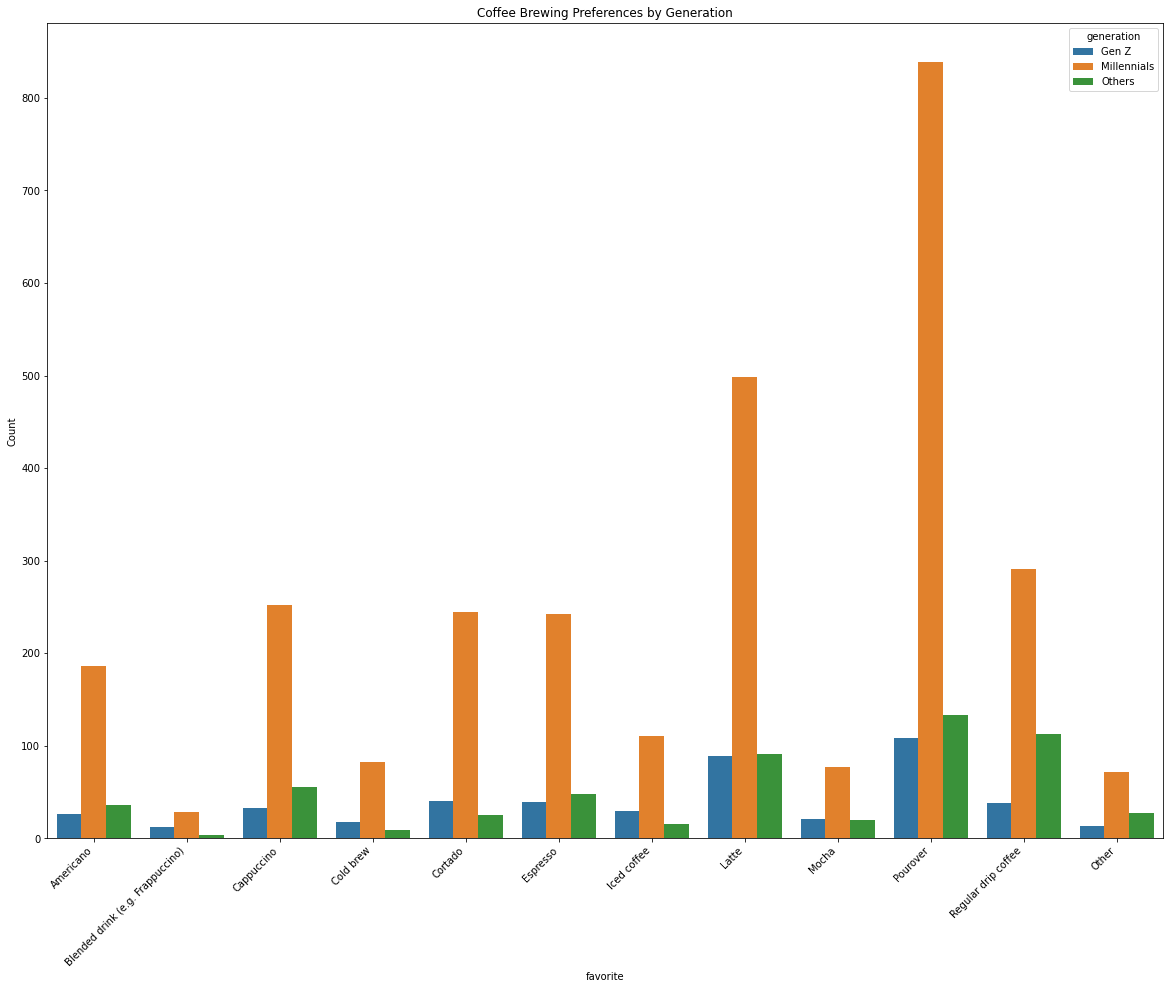

In [116]:
# Clean the 'favorite' column - Remove rows with NaN/empty values
df_cleaned_favorite = df_cleaned.dropna(subset=['favorite']) 
df_cleaned_favorite = df_cleaned_favorite[df_cleaned_favorite['favorite'] != '']

df_cleaned_favorite.loc[:, 'generation'] = df_cleaned_favorite['age'].apply(categorize_generation)

df_exploded_favorite = df_cleaned_favorite.explode('favorite')

df_exploded_favorite['favorite'] = df_exploded_favorite['favorite'].str.strip()

# Count occurrences of each favorite by generation
favorite_counts = df_exploded_favorite.groupby(['generation', 'favorite']).size().reset_index(name='count')

# Visualize with a bar plot
favorite_order = [x for x in favorite_counts['favorite'].unique() if x != 'Other'] + ['Other']
plt.figure(figsize=(20, 15))
sns.barplot(x='favorite', y='count', hue='generation', data=favorite_counts, order=favorite_order) 
plt.title('Coffee Brewing Preferences by Generation')
plt.xticks(rotation=45, ha='right') 
plt.xlabel('favorite')
plt.ylabel('Count')
plt.show()

### Saving CSV files for Voyant Word Cloud

In [117]:
# Filter the data by each generation
df_gen_z = df_exploded_favorite[df_exploded_favorite['generation'] == 'Gen Z'].copy()
df_millennials = df_exploded_favorite[df_exploded_favorite['generation'] == 'Millennials'].copy()
df_others = df_exploded_favorite[df_exploded_favorite['generation'] == 'Others'].copy()

# Clean the 'favorite' column - Remove spaces 
df_gen_z.loc[:, 'favorite'] = df_gen_z['favorite'].str.replace(' ', '', regex=False)
df_millennials.loc[:, 'favorite'] = df_millennials['favorite'].str.replace(' ', '', regex=False)
df_others.loc[:, 'favorite'] = df_others['favorite'].str.replace(' ', '', regex=False)

df_gen_z_favorites = df_gen_z[['favorite']]
df_millennials_favorites = df_millennials[['favorite']]
df_others_favorites = df_others[['favorite']]

# Save to CSV for Voyant tools
df_gen_z_favorites.to_csv('gen_z_favorites.csv', header=False, index=False)
df_millennials_favorites.to_csv('millennials_favorites.csv', header=False, index=False)
df_others_favorites.to_csv('others_favorites.csv', header=False, index=False)


### Normalized Bar Chart

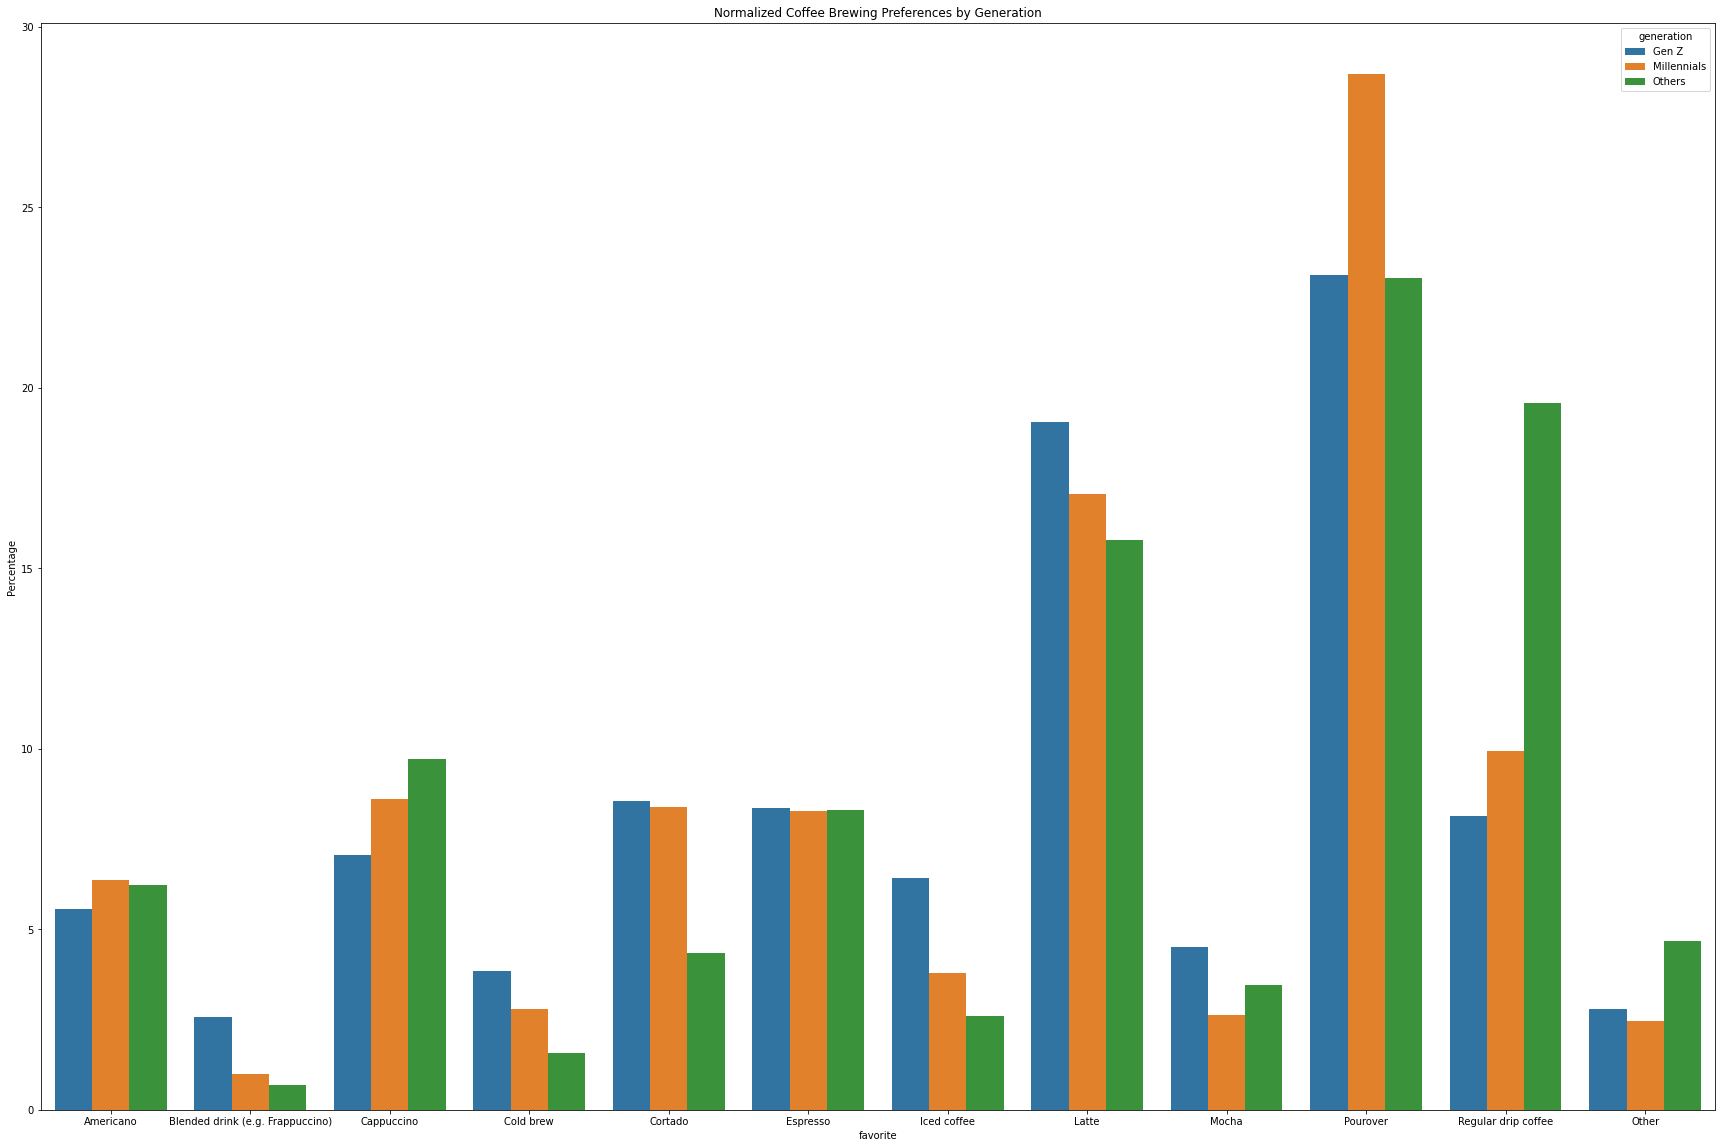

In [118]:
grouped_favorite = df_exploded_favorite.groupby(['generation', 'favorite']).size().reset_index(name='count')

# Normalize the count within each generation
grouped_favorite['total_per_generation'] = grouped_favorite.groupby('generation')['count'].transform('sum')
grouped_favorite['percentage'] = (grouped_favorite['count'] / grouped_favorite['total_per_generation']) * 100

# Visualization
grouped_favorite_order = [
    'Americano', 'Blended drink (e.g. Frappuccino)', 'Cappuccino', 'Cold brew', 
    'Cortado', 'Espresso', 'Iced coffee', 'Latte', 'Mocha', 'Pourover', 'Regular drip coffee', 
    'Other']
plt.figure(figsize=(30,20))
sns.barplot(data=grouped_favorite, x='favorite', y='percentage', hue='generation', order=grouped_favorite_order)
plt.title('Normalized Coffee Brewing Preferences by Generation')
plt.ylabel('Percentage')
plt.show()


### 4.2.2 Coffee Style Preferences by Generations

### Bar Chart

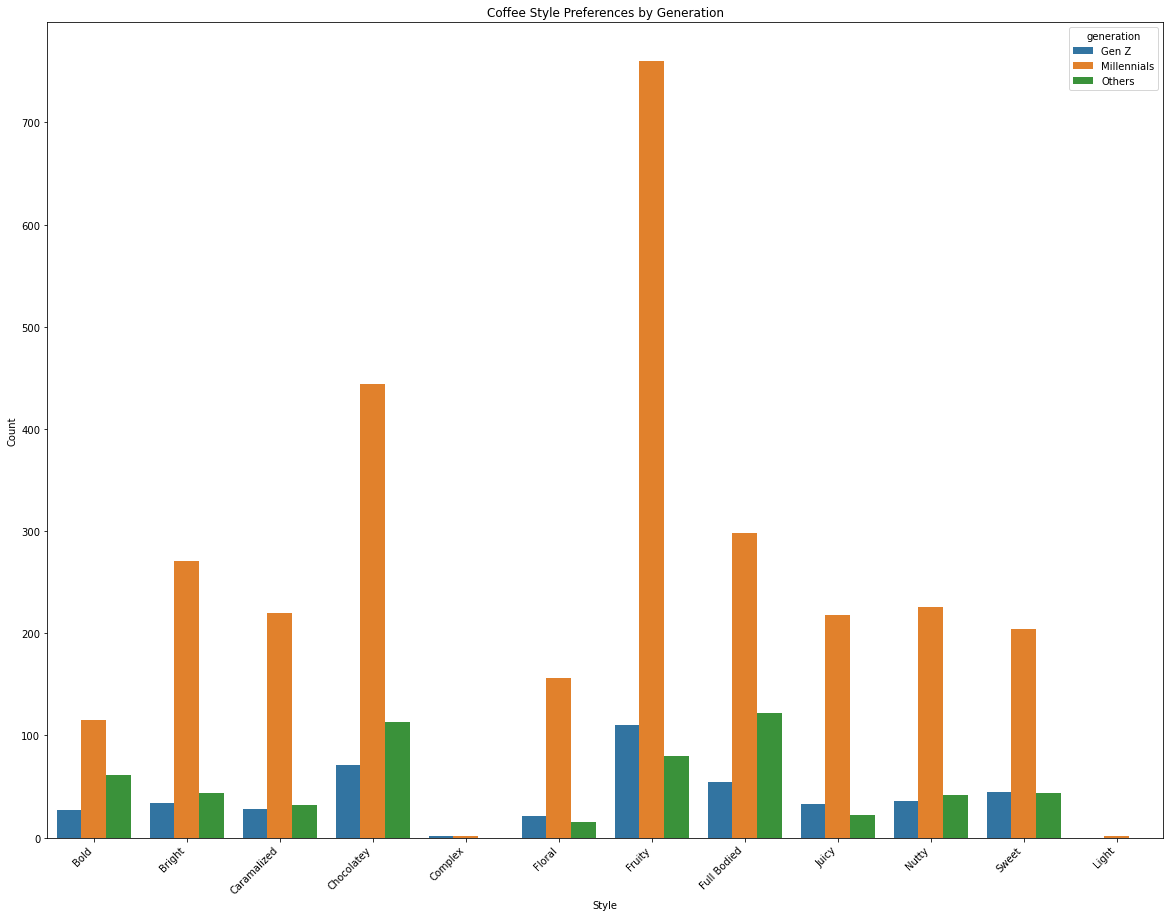

In [119]:
# Clean the 'style' column - Remove rows with NaN/empty values
df_cleaned_style = df_cleaned.dropna(subset=['style']) 
df_cleaned_style = df_cleaned_style[df_cleaned_style['style'] != ''] 

df_cleaned_style.loc[:, 'generation'] = df_cleaned_style['age'].apply(categorize_generation)

df_exploded_style = df_cleaned_style.explode('style')

df_exploded_style['style'] = df_exploded_style['style'].str.strip()

# Count occurrences of each style by generation
style_counts = df_exploded_style.groupby(['generation', 'style']).size().reset_index(name='count')

# Visualize with a bar plot
plt.figure(figsize=(20, 15))
sns.barplot(x='style', y='count', hue='generation', data=style_counts) 
plt.title('Coffee Style Preferences by Generation')
plt.xticks(rotation=45, ha='right') 
plt.xlabel('Style')
plt.ylabel('Count')
plt.show()

### Normalized Bar Chart

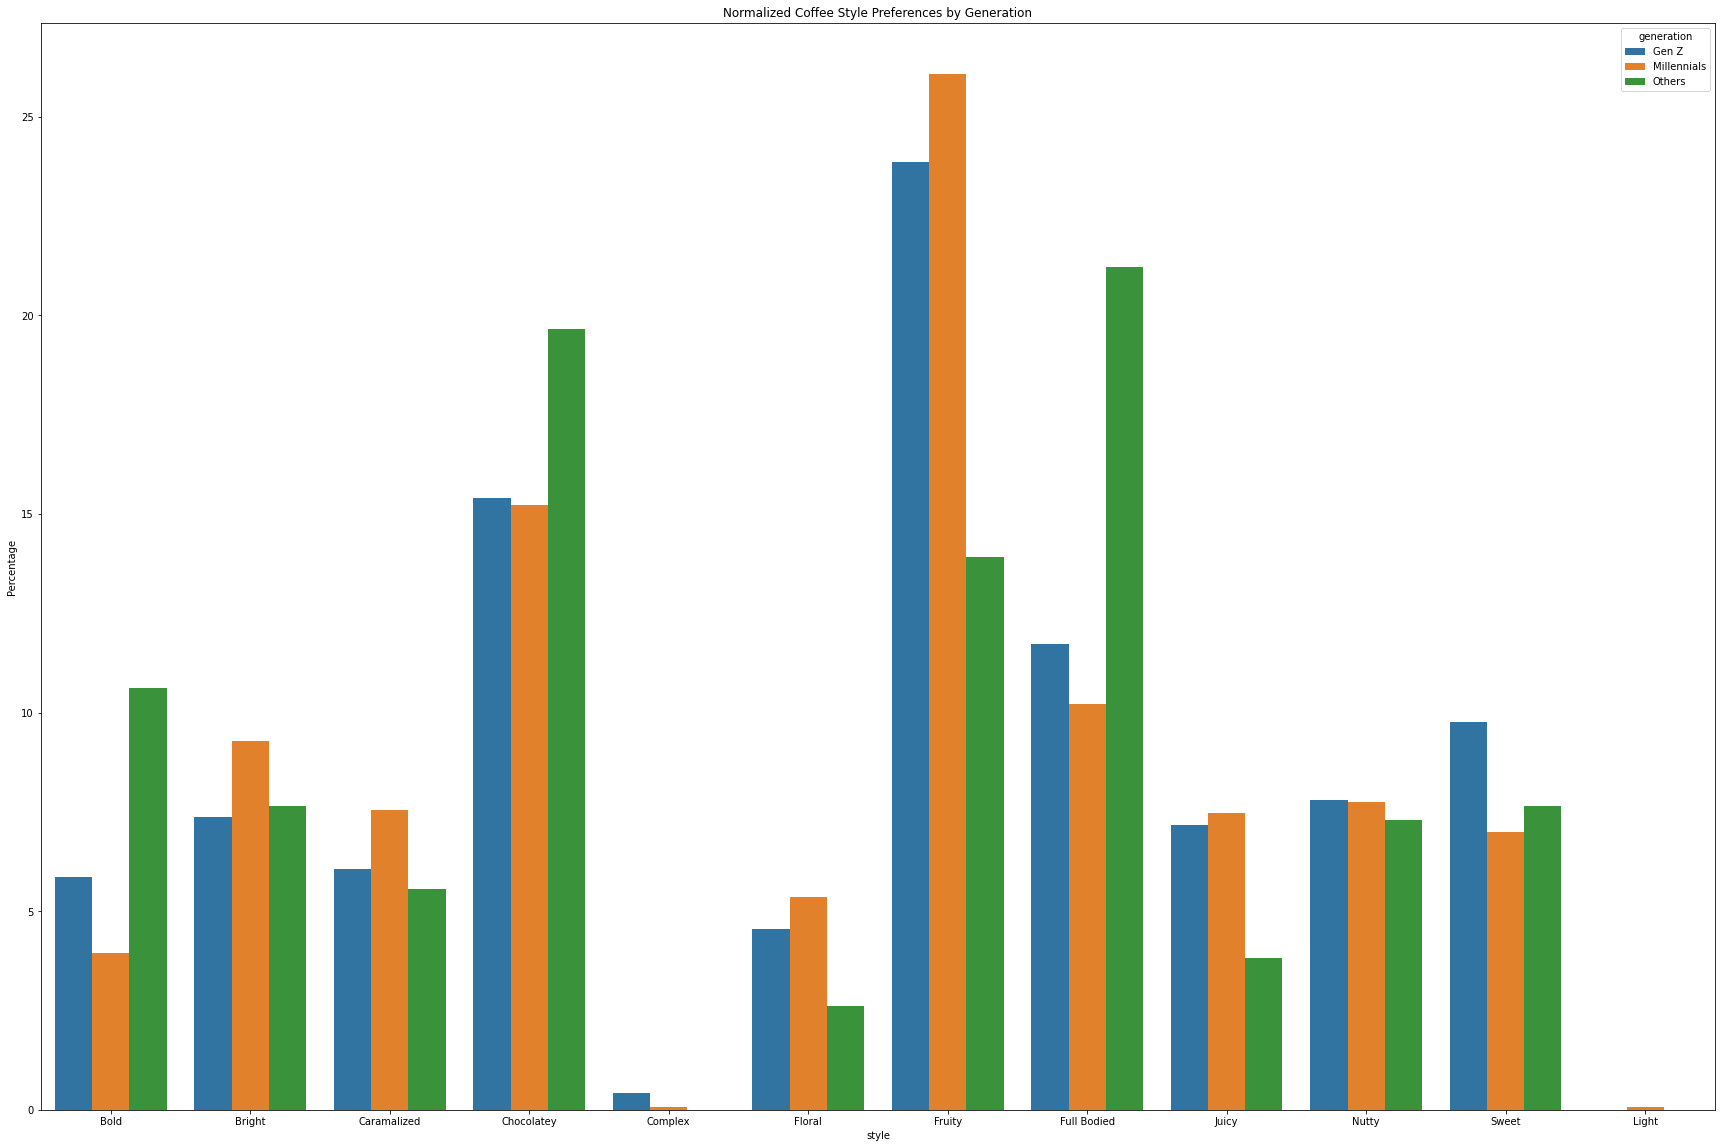

In [120]:
grouped_style = df_exploded_style.groupby(['generation', 'style']).size().reset_index(name='count')

# Normalize the count within each generation
grouped_style['total_per_generation'] = grouped_style.groupby('generation')['count'].transform('sum')
grouped_style['percentage'] = (grouped_style['count'] / grouped_style['total_per_generation']) * 100

# Visualization
plt.figure(figsize=(30,20))
sns.barplot(data=grouped_style, x='style', y='percentage', hue='generation')
plt.title('Normalized Coffee Style Preferences by Generation')
plt.ylabel('Percentage')
plt.show()

### 4.2.3 Coffee Strength Preferences by Generations

### Bar Chart

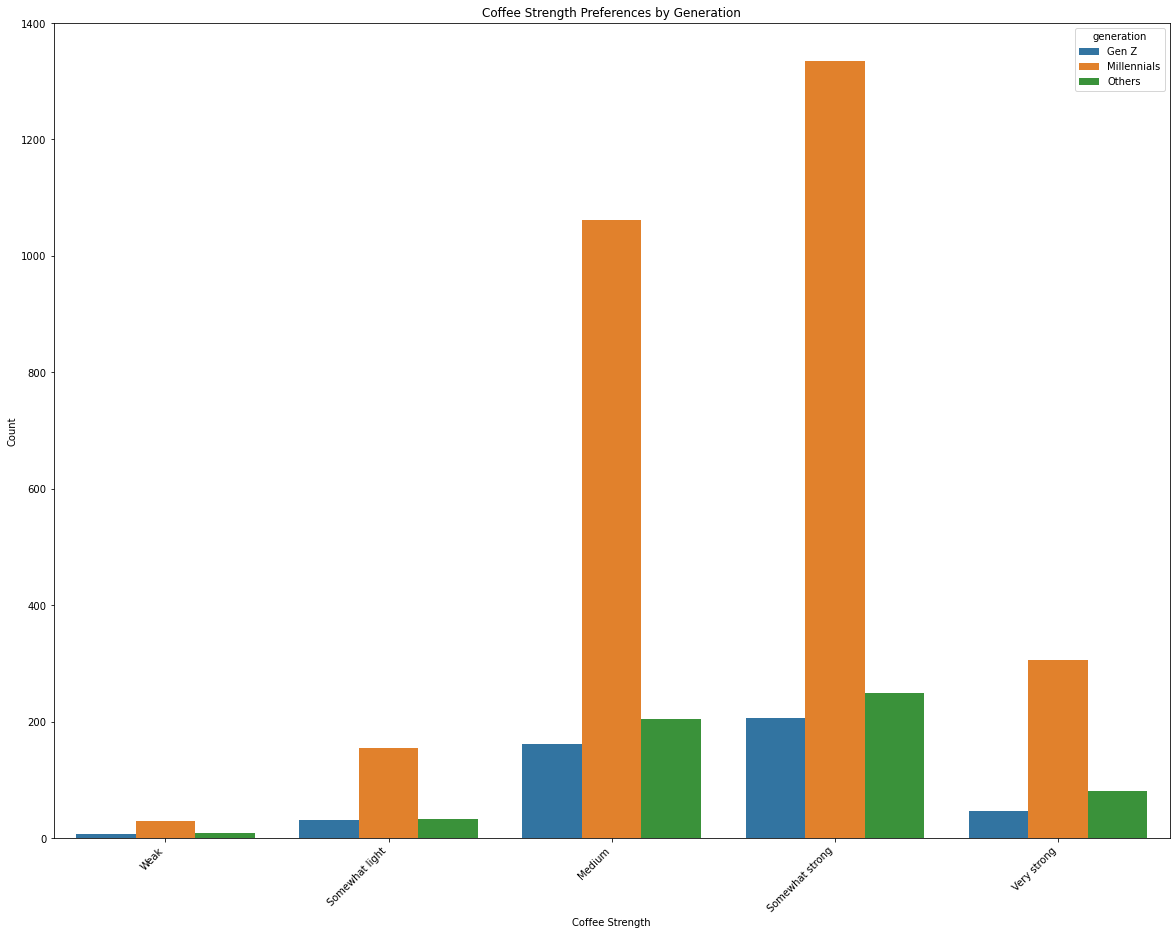

In [121]:
# Clean the 'strength' column - Remove rows with NaN/empty values
df_cleaned_strength = df_cleaned.dropna(subset=['strength'])  
df_cleaned_strength = df_cleaned_strength[df_cleaned_strength['strength'] != ''] 

df_cleaned_strength.loc[:, 'generation'] = df_cleaned_strength['age'].apply(categorize_generation)

df_exploded_strength = df_cleaned_strength.explode('strength')

df_exploded_strength['strength'] = df_exploded_strength['strength'].str.strip()

# Count occurrences of each strength values by generation
strength_counts = df_exploded_strength.groupby(['generation', 'strength']).size().reset_index(name='count')

# Visualize with a bar plot
strength_order = ['Weak', 'Somewhat light', 'Medium', 'Somewhat strong', 'Very strong'] 
plt.figure(figsize=(20, 15))
sns.barplot(x='strength', y='count', hue='generation', data=strength_counts, order=strength_order)
plt.title('Coffee Strength Preferences by Generation')
plt.xticks(rotation=45, ha='right')  
plt.xlabel('Coffee Strength')
plt.ylabel('Count')
plt.show()

### Normalized Bar Chart

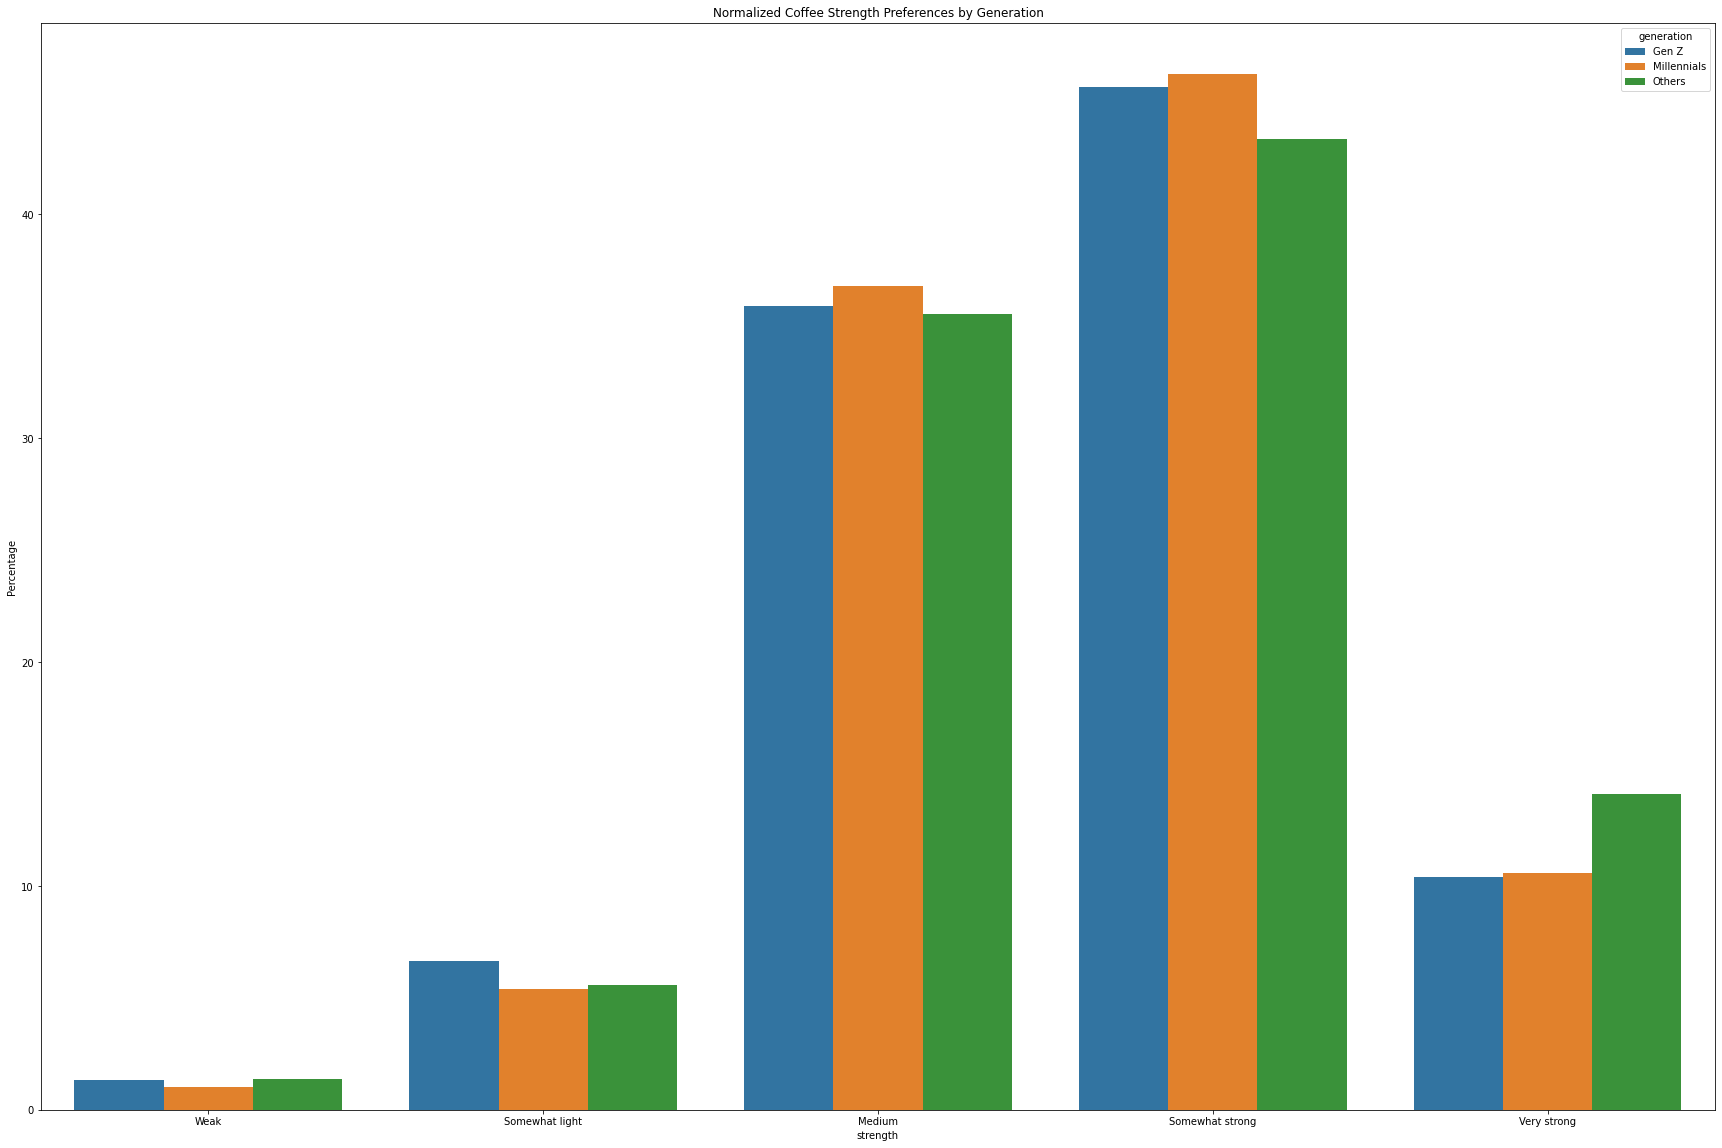

In [122]:
grouped_strength = df_exploded_strength.groupby(['generation', 'strength']).size().reset_index(name='count')

# Normalize the count within each generation
grouped_strength['total_per_generation'] = grouped_strength.groupby('generation')['count'].transform('sum')
grouped_strength['percentage'] = (grouped_strength['count'] / grouped_strength['total_per_generation']) * 100

# Visualization
grouped_strength_order = ['Weak', 'Somewhat light', 'Medium', 'Somewhat strong', 'Very strong'] 
plt.figure(figsize=(30,20))
sns.barplot(data=grouped_strength, x='strength', y='percentage', hue='generation', order=grouped_strength_order)
plt.title('Normalized Coffee Strength Preferences by Generation')
plt.ylabel('Percentage')
plt.show()

### 4.2.4 Coffee Roast Level Preferences by Generations

### Bar Chart

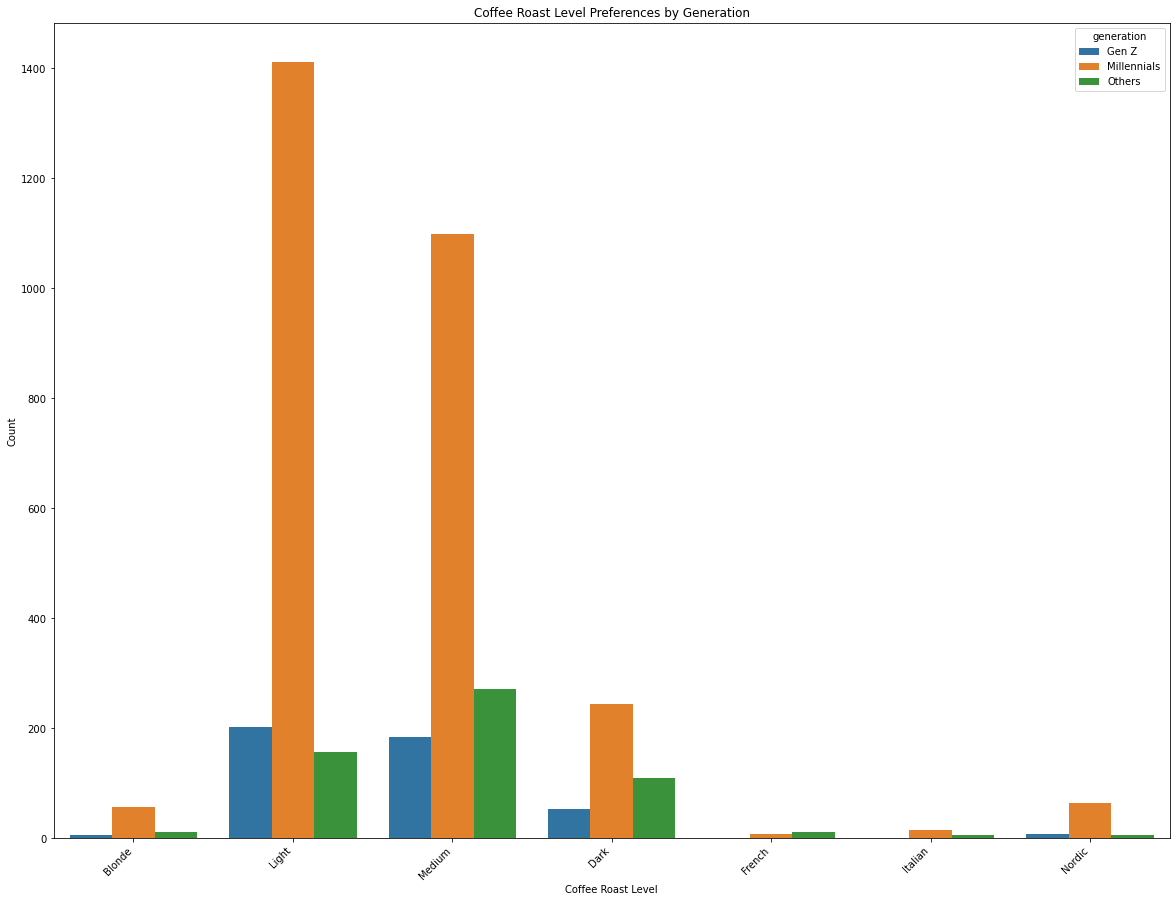

In [123]:
# Clean the 'roast_level' column - Remove rows with NaN/empty values
df_cleaned_roast_level = df_cleaned.dropna(subset=['roast_level'])  
df_cleaned_roast_level = df_cleaned_roast_level[df_cleaned_roast_level['roast_level'] != '']  

df_cleaned_roast_level.loc[:, 'generation'] = df_cleaned_roast_level['age'].apply(categorize_generation)

df_exploded_roast_level = df_cleaned_roast_level.explode('roast_level')

df_exploded_roast_level['roast_level'] = df_exploded_roast_level['roast_level'].str.strip()

# Count occurrences of each roast_level values by generation
roast_level_counts = df_exploded_roast_level.groupby(['generation', 'roast_level']).size().reset_index(name='count')

# Visualize with a bar plot
roast_level_order = ['Blonde', 'Light', 'Medium', 'Dark', 'French', 'Italian', 'Nordic'] 
plt.figure(figsize=(20, 15))
sns.barplot(x='roast_level', y='count', hue='generation', data=roast_level_counts, order=roast_level_order)  
plt.title('Coffee Roast Level Preferences by Generation')
plt.xticks(rotation=45, ha='right') 
plt.xlabel('Coffee Roast Level')
plt.ylabel('Count')
plt.show()

### Normalized Bar Chart

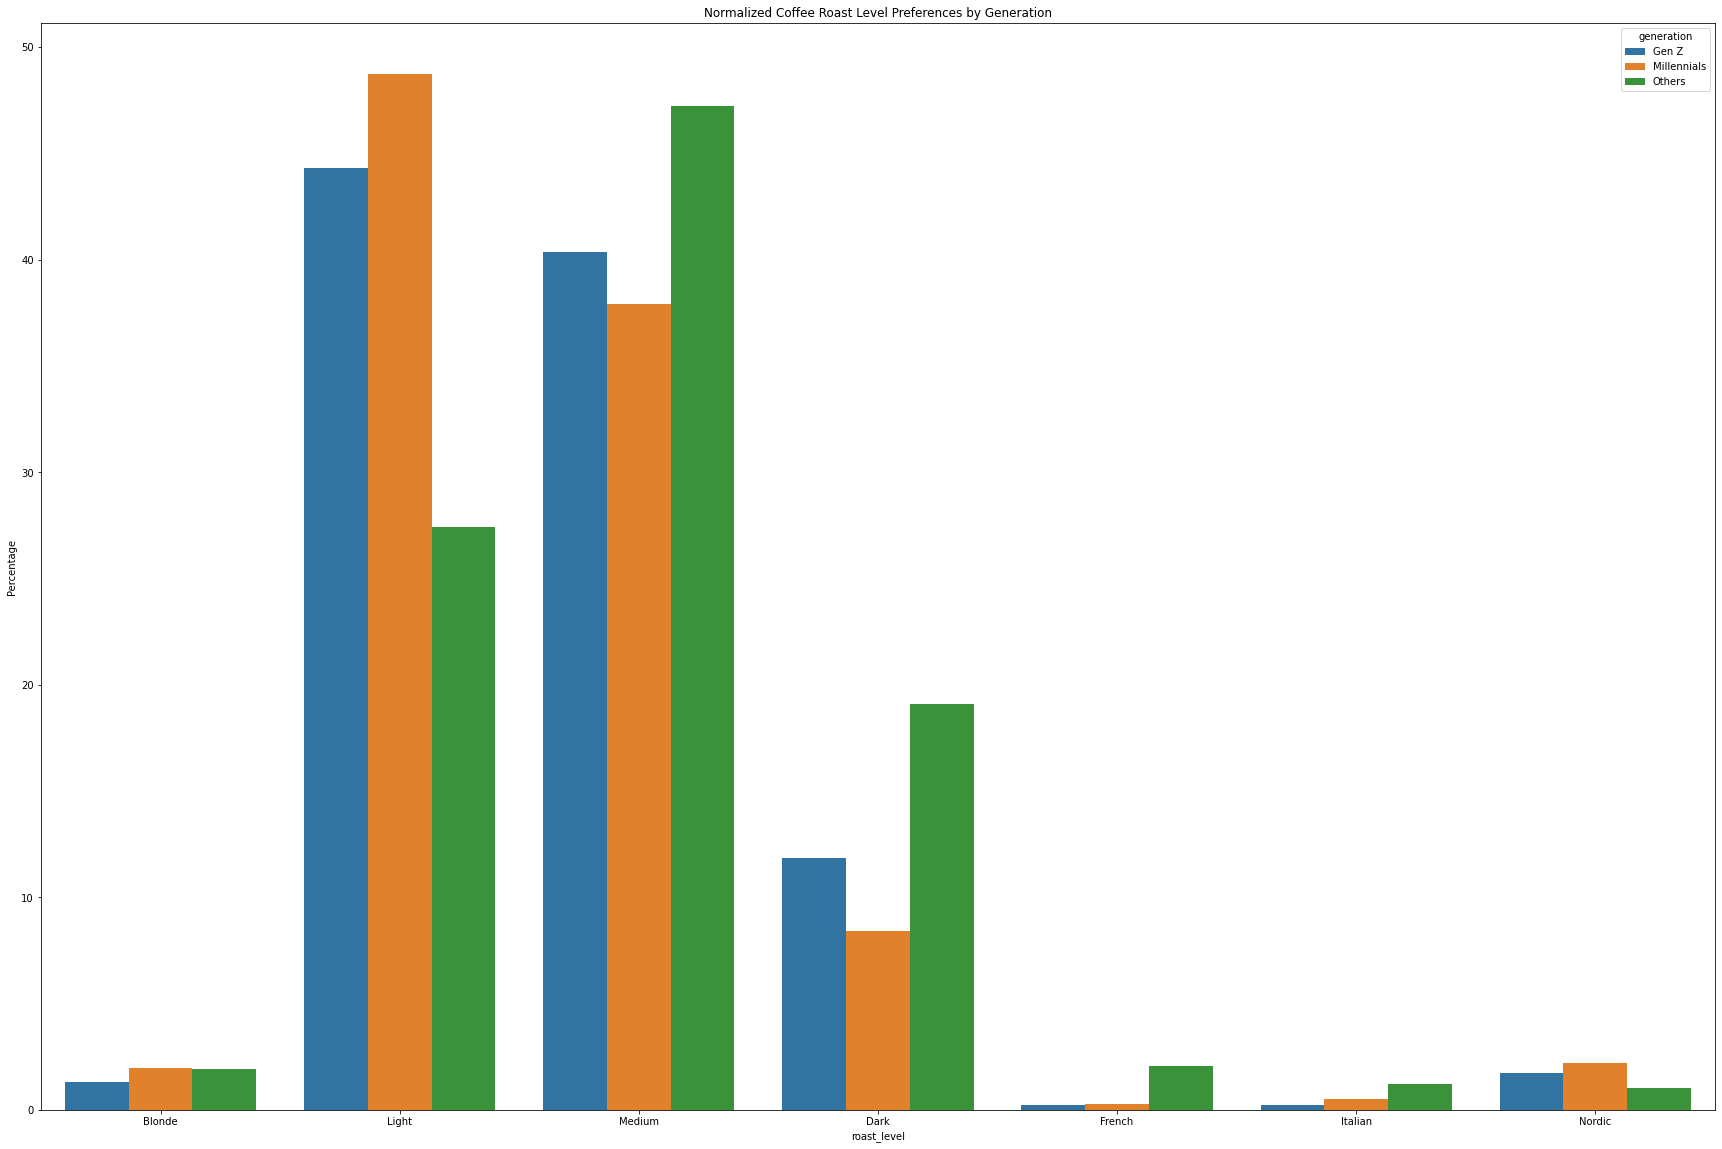

In [124]:
grouped_roast_level = df_exploded_roast_level.groupby(['generation', 'roast_level']).size().reset_index(name='count')

# Normalize the count within each generation
grouped_roast_level['total_per_generation'] = grouped_roast_level.groupby('generation')['count'].transform('sum')
grouped_roast_level['percentage'] = (grouped_roast_level['count'] / grouped_roast_level['total_per_generation']) * 100

# Visualization
grouped_roast_level_order = ['Blonde', 'Light', 'Medium', 'Dark', 'French', 'Italian', 'Nordic'] 
plt.figure(figsize=(30,20))
sns.barplot(data=grouped_roast_level, x='roast_level', y='percentage', hue='generation', order=grouped_roast_level_order)
plt.title('Normalized Coffee Roast Level Preferences by Generation')
plt.ylabel('Percentage')
plt.show()

### 4.2.5 Coffee Caffeine Preferences by Generations

### Bar Chart

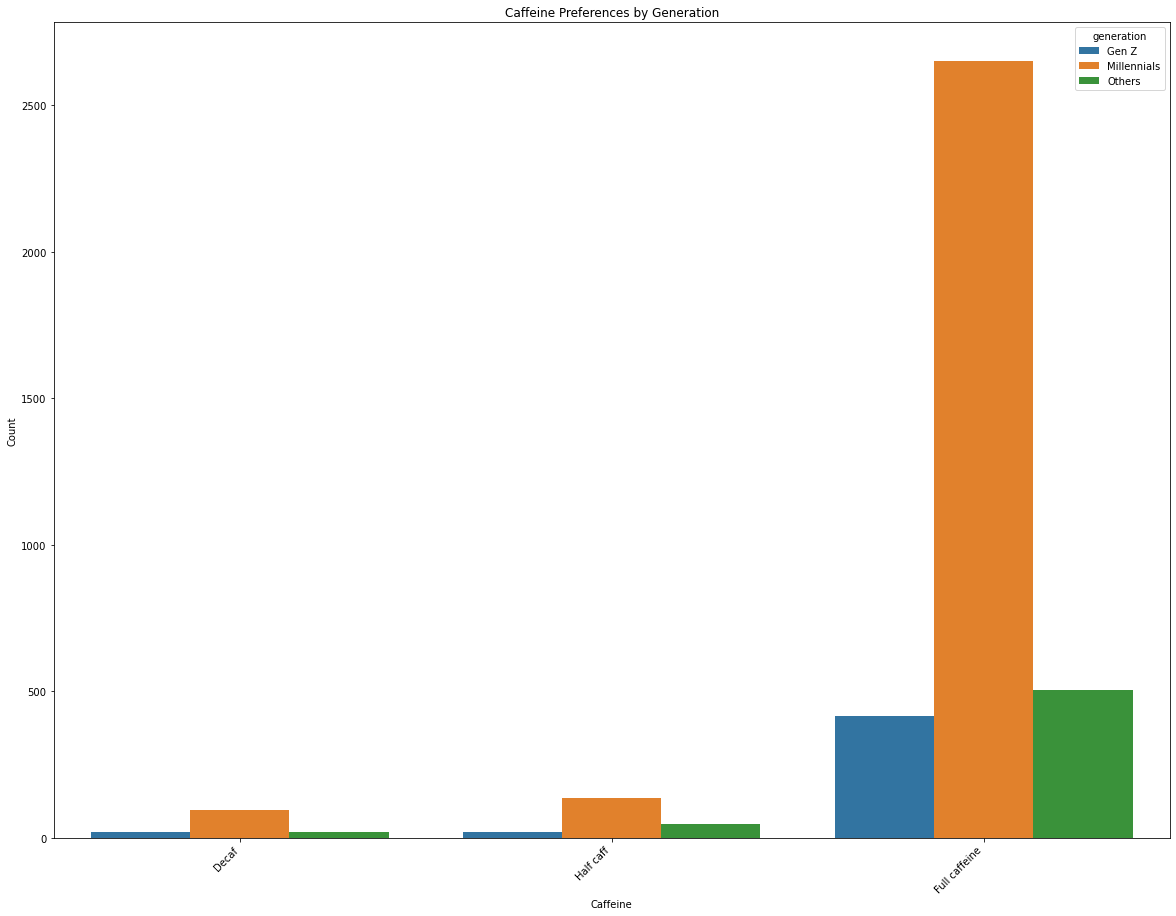

In [125]:
# Clean the 'caffeine' column - Remove rows with NaN/empty values
df_cleaned_caffeine = df_cleaned.dropna(subset=['caffeine'])  
df_cleaned_caffeine = df_cleaned_caffeine[df_cleaned_caffeine['caffeine'] != ''] 

df_cleaned_caffeine.loc[:, 'generation'] = df_cleaned_caffeine['age'].apply(categorize_generation)

df_exploded_caffeine = df_cleaned_caffeine.explode('caffeine')

df_exploded_caffeine['caffeine'] = df_exploded_caffeine['caffeine'].str.strip()

# Count occurrences of each caffeine values by generation
caffeine_counts = df_exploded_caffeine.groupby(['generation', 'caffeine']).size().reset_index(name='count')

# Visualize with a bar plot
caffeine_order = ['Decaf', 'Half caff', 'Full caffeine'] 
plt.figure(figsize=(20, 15))
sns.barplot(x='caffeine', y='count', hue='generation', data=caffeine_counts, order=caffeine_order)  
plt.title('Caffeine Preferences by Generation')
plt.xticks(rotation=45, ha='right') 
plt.xlabel('Caffeine')
plt.ylabel('Count')
plt.show()

### Normalized Bar Chart

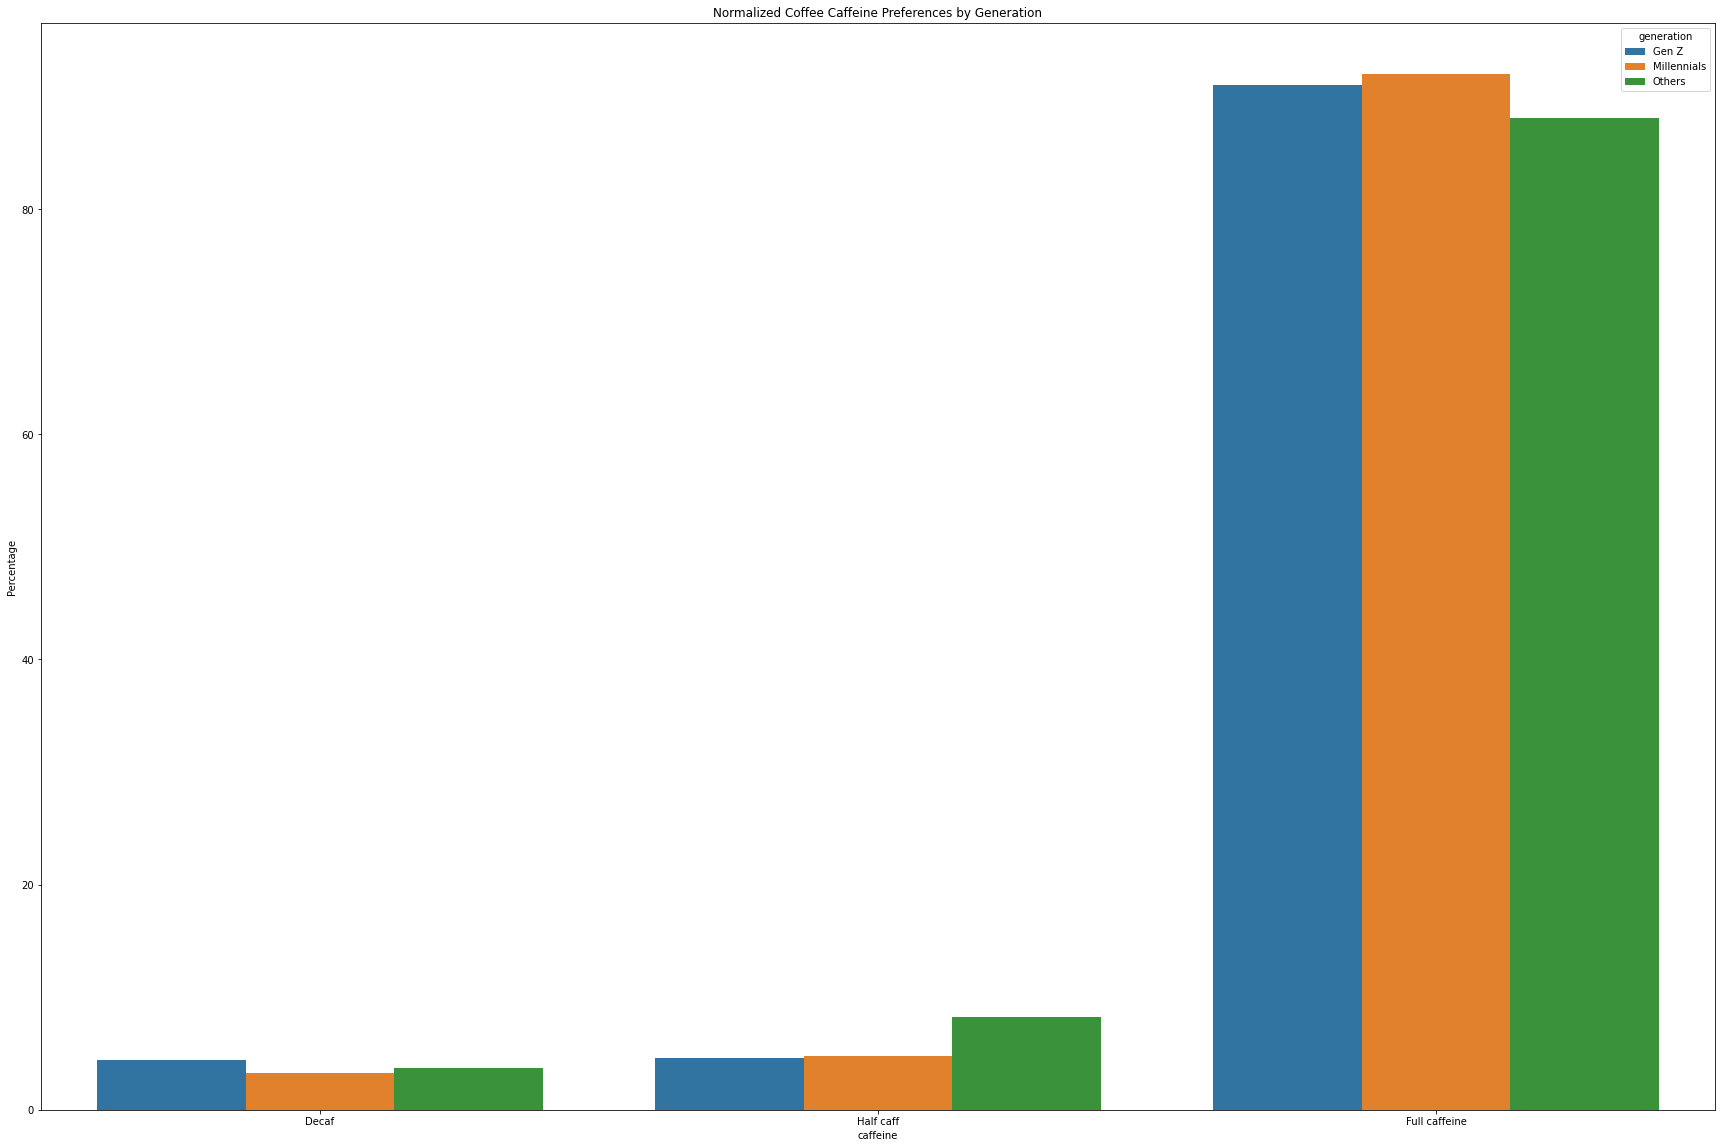

In [126]:
grouped_caffeine = df_exploded_caffeine.groupby(['generation', 'caffeine']).size().reset_index(name='count')

# Normalize the count within each generation
grouped_caffeine['total_per_generation'] = grouped_caffeine.groupby('generation')['count'].transform('sum')
grouped_caffeine['percentage'] = (grouped_caffeine['count'] / grouped_caffeine['total_per_generation']) * 100

# Visualization
grouped_caffeine_order = ['Decaf', 'Half caff', 'Full caffeine'] 
plt.figure(figsize=(30,20))
sns.barplot(data=grouped_caffeine, x='caffeine', y='percentage', hue='generation', order=grouped_caffeine_order)
plt.title('Normalized Coffee Caffeine Preferences by Generation')
plt.ylabel('Percentage')
plt.show()

### Stacked Bar Chart

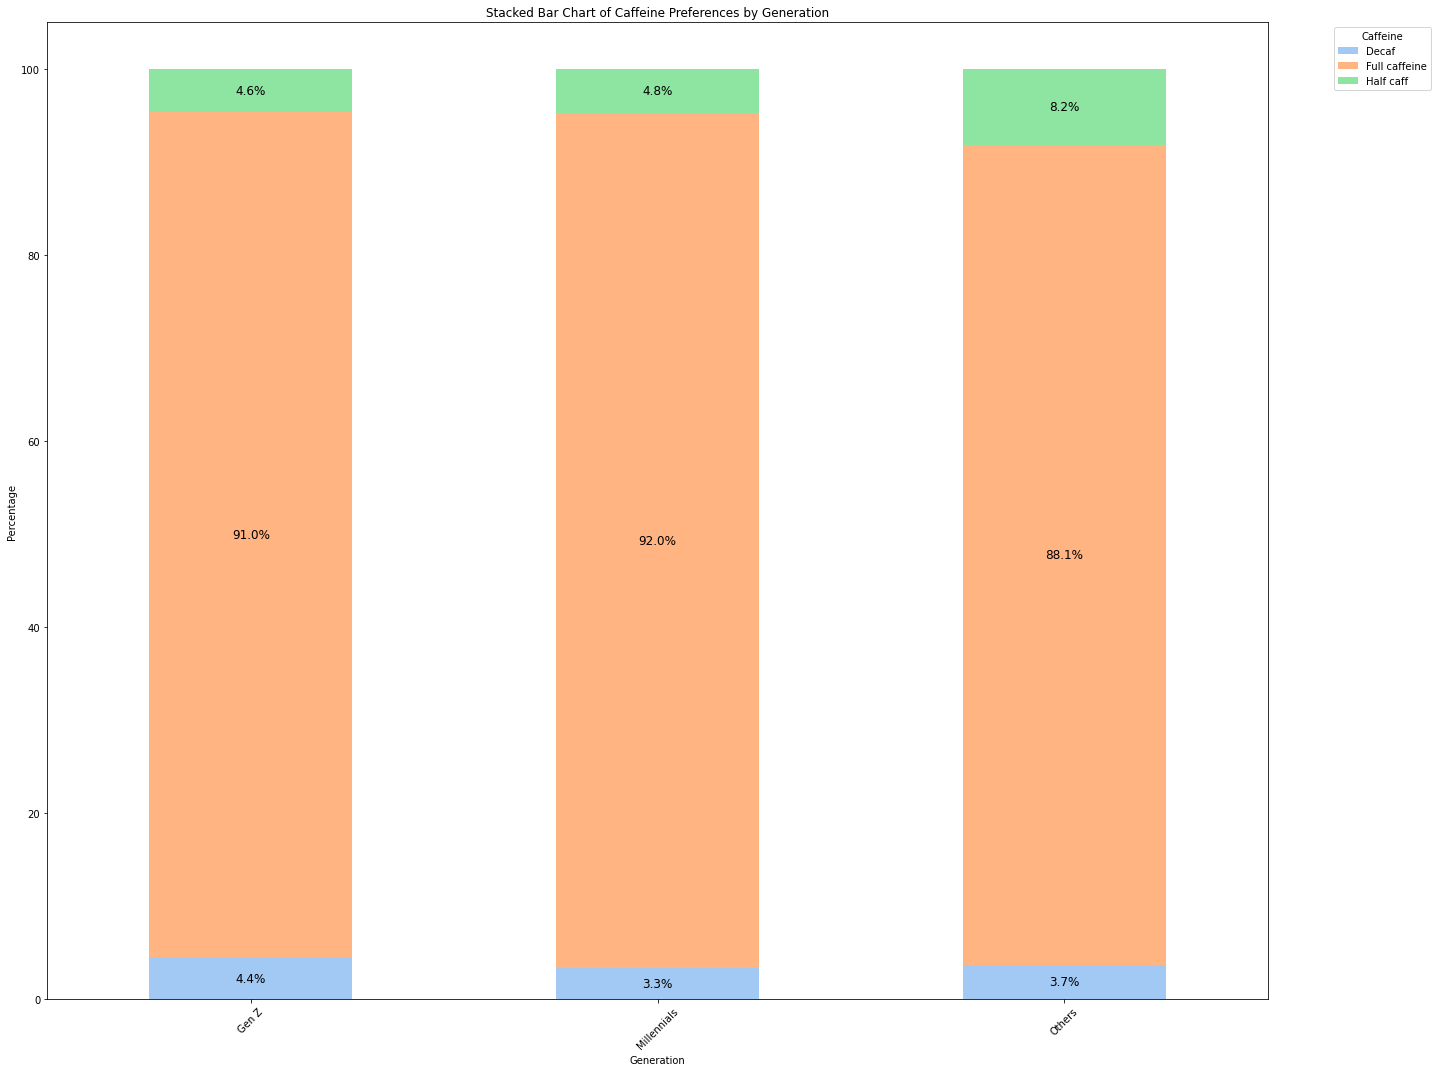

In [127]:
# Pivot the data to get caffeine preferences as columns for each generation
pivoted_caffeine = grouped_caffeine.pivot_table(index='generation', columns='caffeine', values='count', aggfunc='sum', fill_value=0)

# Normalize the data 
pivoted_caffeine_percentage = pivoted_caffeine.div(pivoted_caffeine.sum(axis=1), axis=0) * 100

# Visualize with a stacked bar chart
colors = sns.color_palette("pastel", n_colors=3)
ax = pivoted_caffeine_percentage.plot(kind='bar', stacked=True, figsize=(20, 15), color=colors)

for p in ax.patches:            # Annotate the bars with the percentage values
    height = p.get_height()
    width = p.get_width()
    x_position = p.get_x() + width / 2  
    y_position = p.get_y() + height / 2  
    
    if height > 0: 
        ax.annotate(f'{height:.1f}%', (x_position, y_position),
                    ha='center', va='center', fontsize=12, color='black')

plt.title('Stacked Bar Chart of Caffeine Preferences by Generation')
plt.xlabel('Generation')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(title='Caffeine', bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.tight_layout()
plt.show()



### 4.2.6 Most Willing Amount to Pay by Generations

### Bar Chart

     most_willing  most_willing_numeric
34         $8-$10                     5
41  More than $20                     8
42  More than $20                     8
43        $15-$20                     7
46          $4-$6                     3


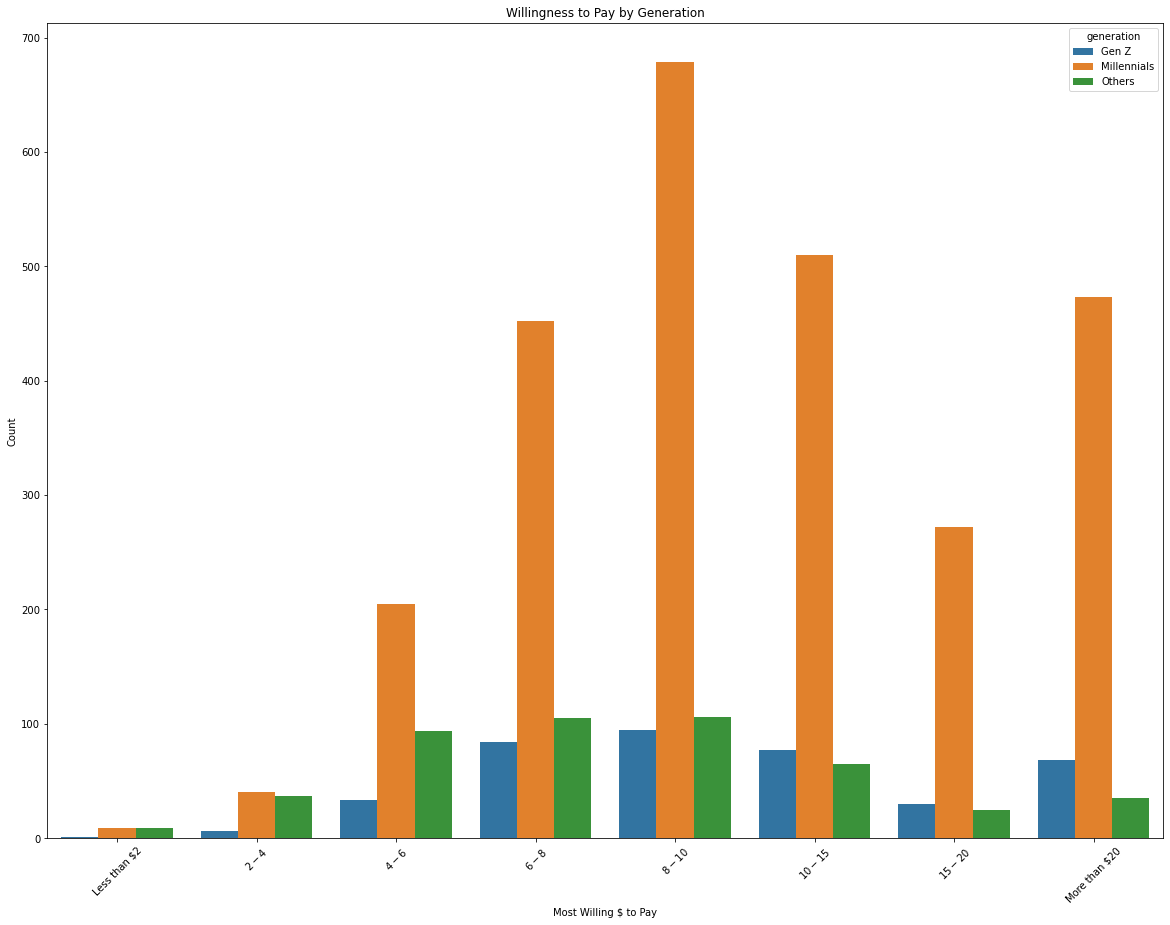

In [128]:
# Clean the 'most_willing' column - Remove rows with NaN/empty values
df_cleaned_most_willing = df_cleaned.dropna(subset=['most_willing']) 
df_cleaned_most_willing = df_cleaned_most_willing[df_cleaned_most_willing['most_willing'] != '']  

df_cleaned_most_willing['most_willing'] = df_cleaned_most_willing['most_willing'].str.strip()

df_cleaned_most_willing.loc[:, 'generation'] = df_cleaned_most_willing['age'].apply(categorize_generation)

# Map 'most_willing' values to numeric values
def map_willingness_to_numeric(wtp):
    if 'Less than $2' in wtp:
        return 1
    elif '$2-$4' in wtp:
        return 2
    elif '$4-$6' in wtp:
        return 3
    elif '$6-$8' in wtp:
        return 4
    elif '$8-$10' in wtp:
        return 5
    elif '$10-$15' in wtp:
        return 6
    elif '$15-$20' in wtp:
        return 7
    elif 'More than $20' in wtp:
        return 8
    return None 

df_cleaned_most_willing['most_willing_numeric'] = df_cleaned_most_willing['most_willing'].apply(map_willingness_to_numeric)   # Apply the mapping to the 'most_willing' column

print(df_cleaned_most_willing[['most_willing', 'most_willing_numeric']].head())

# Count occurrences of each willingness-to-pay value by generation
most_willing_counts = df_cleaned_most_willing.groupby(['generation', 'most_willing_numeric']).size().reset_index(name='count')

# Visualize with a bar plot
wtp_order = [1, 2, 3, 4, 5, 6, 7, 8]  # Custom numeric order for most_willing values
plt.figure(figsize=(20, 15))
sns.barplot(x='most_willing_numeric', y='count', hue='generation', data=most_willing_counts, order=wtp_order)  
plt.title('Willingness to Pay by Generation')
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6, 7], labels=['Less than $2', '$2-$4', '$4-$6', '$6-$8', '$8-$10', '$10-$15', '$15-$20', 'More than $20'], rotation=45)
plt.xlabel('Most Willing $ to Pay')
plt.ylabel('Count')
plt.show()

### Box Plot

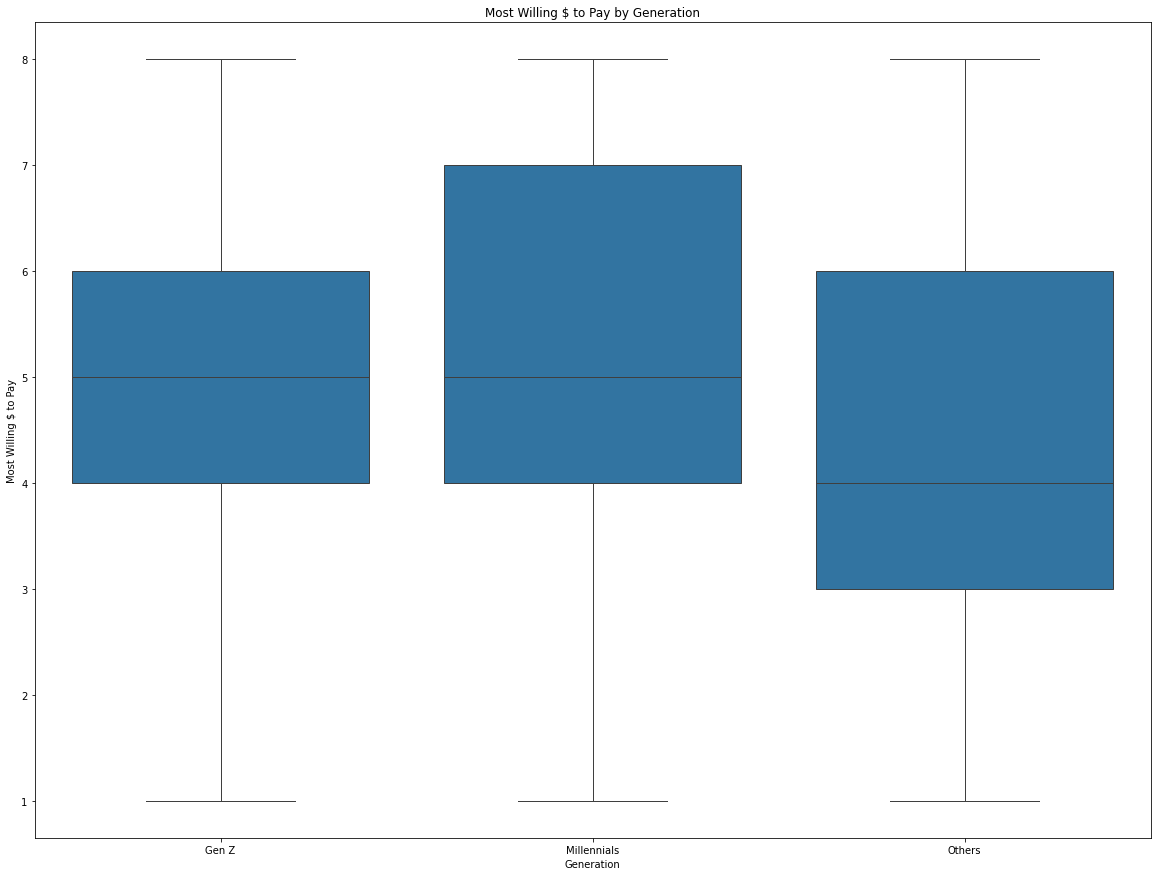

In [129]:
# Visualize with a box plot
willingness_to_pay_order = ['Gen Z', 'Millennials', 'Others'] 
plt.figure(figsize=(20, 15))
sns.boxplot(x='generation', y='most_willing_numeric', data=df_cleaned_most_willing, order=willingness_to_pay_order)
plt.title('Most Willing $ to Pay by Generation')
plt.xlabel('Generation')
plt.ylabel('Most Willing $ to Pay')
plt.show()

# 5. Millennial & Gen Z Taste Profiles

## 5.1 Identify the Most Common Combination (Taste Profile)

In [130]:
# Clean the relevant columns - Remove rows with NaN/empty values in 'favorite', 'style', 'strength'
df_cleaned_combination = df_cleaned.copy()

df_cleaned_combination = df_cleaned_combination[
    (df_cleaned_combination['favorite'].notna()) &
    (df_cleaned_combination['favorite'] != '') &
    (df_cleaned_combination['style'].notna()) &
    (df_cleaned_combination['style'] != '') &
    (df_cleaned_combination['strength'].notna()) &
    (df_cleaned_combination['strength'] != '')
]

# Combine favorite brewing method, flavor, strength, and sweetener into a new column "Taste_Profile"
df_cleaned_combination['Taste_Profile'] = (
    df_cleaned_combination['favorite'] + ' + ' +
    df_cleaned_combination['style'] + ' + ' +
    df_cleaned_combination['strength']
)


# Group by the 'Taste_Profile' and count occurrences
taste_profile_counts = df_cleaned_combination.groupby('Taste_Profile').size().reset_index(name='count')

# Sort the combinations by count in descending order
most_common_profiles = taste_profile_counts.sort_values(by='count', ascending=False)

# Display the most common combinations
print(most_common_profiles.head(10))

# Adjust pandas display options to show the full table without truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Display the full table with combinations
display(most_common_profiles)


                             Taste_Profile  count
349    Pourover + Fruity + Somewhat strong    168
347             Pourover + Fruity + Medium    162
236            Latte + Chocolatey + Medium     71
238   Latte + Chocolatey + Somewhat strong     70
355              Pourover + Juicy + Medium     57
357     Pourover + Juicy + Somewhat strong     55
332    Pourover + Bright + Somewhat strong     54
330             Pourover + Bright + Medium     50
251  Latte + Full Bodied + Somewhat strong     48
138     Cortado + Fruity + Somewhat strong     48


,Taste_Profile,count
349,Pourover + Fruity + Somewhat strong,168
347,Pourover + Fruity + Medium,162
236,Latte + Chocolatey + Medium,71
238,Latte + Chocolatey + Somewhat strong,70
355,Pourover + Juicy + Medium,57
357,Pourover + Juicy + Somewhat strong,55
332,Pourover + Bright + Somewhat strong,54
330,Pourover + Bright + Medium,50
251,Latte + Full Bodied + Somewhat strong,48
138,Cortado + Fruity + Somewhat strong,48


## 5.2 Identify the Most Common Combination by Generation (Taste Profile by Generation)

In [131]:
# Filter data for Millennials and Gen Z
df_cleaned_age_millennials = df_cleaned_age[df_cleaned_age['generation'] == 'Millennials'].copy()
df_cleaned_age_gen_z = df_cleaned_age[df_cleaned_age['generation'] == 'Gen Z'].copy()
df_cleaned_age_others = df_cleaned_age[df_cleaned_age['generation'] == 'Others'].copy()

# Create bundled preferences by combining brewing method, style, and strength
df_cleaned_age_millennials.loc[:, 'taste_profile'] = (df_cleaned_age_millennials['favorite'] + ' + ' +
                                                      df_cleaned_age_millennials['style'] + ' + ' +
                                                      df_cleaned_age_millennials['strength'])

df_cleaned_age_gen_z.loc[:, 'taste_profile'] = (df_cleaned_age_gen_z['favorite'] + ' + ' +
                                                df_cleaned_age_gen_z['style'] + ' + ' +
                                                df_cleaned_age_gen_z['strength'])


df_cleaned_age_others.loc[:, 'taste_profile'] = (df_cleaned_age_others['favorite'] + ' + ' +
                                                df_cleaned_age_others['style'] + ' + ' +
                                                df_cleaned_age_others['strength'])

# Count the occurrences of each bundled preference for each generation
millennials_taste_profile_counts = df_cleaned_age_millennials['taste_profile'].value_counts().reset_index(name='count')
gen_z_taste_profile_counts = df_cleaned_age_gen_z['taste_profile'].value_counts().reset_index(name='count')
others_taste_profile_counts = df_cleaned_age_others['taste_profile'].value_counts().reset_index(name='count')

# Rename columns for clarity
millennials_taste_profile_counts.columns = ['Millennials_Taste Profile', 'Count']
gen_z_taste_profile_counts.columns = ['Gen Z_Taste Profile', 'Count']
others_taste_profile_counts.columns = ['Others_Taste Profile', 'Count']

# Display as table format
display(millennials_taste_profile_counts.head(10))
display(gen_z_taste_profile_counts.head(10))
display(others_taste_profile_counts.head(10))

,Millennials_Taste Profile,Count
0,Pourover + Fruity + Medium,139
1,Pourover + Fruity + Somewhat strong,131
2,Latte + Chocolatey + Medium,55
3,Latte + Chocolatey + Somewhat strong,52
4,Pourover + Juicy + Somewhat strong,50
5,Cortado + Fruity + Somewhat strong,42
6,Pourover + Bright + Somewhat strong,42
7,Pourover + Juicy + Medium,40
8,Pourover + Bright + Medium,38
9,Latte + Full Bodied + Somewhat strong,36


,Gen Z_Taste Profile,Count
0,Pourover + Fruity + Somewhat strong,19
1,Pourover + Juicy + Medium,10
2,Latte + Sweet + Medium,10
3,Pourover + Fruity + Medium,9
4,Latte + Fruity + Medium,8
5,Latte + Chocolatey + Medium,7
6,Pourover + Bright + Somewhat strong,7
7,Mocha + Chocolatey + Somewhat strong,6
8,Cortado + Full Bodied + Somewhat strong,6
9,Latte + Chocolatey + Somewhat strong,6


,Others_Taste Profile,Count
0,Pourover + Fruity + Somewhat strong,18
1,Regular drip coffee + Full Bodied + Somewhat strong,17
2,Pourover + Fruity + Medium,13
3,Regular drip coffee + Full Bodied + Medium,12
4,Pourover + Full Bodied + Somewhat strong,12
5,Latte + Chocolatey + Somewhat strong,12
6,Cappuccino + Chocolatey + Somewhat strong,10
7,Latte + Chocolatey + Medium,9
8,Latte + Bold + Somewhat strong,9
9,Pourover + Bright + Medium,8


## 6. Network Analysis

### 6.1 Preparing Dataset for Network Analysis

In [132]:
# Combine all cleaned DataFrames into a single DataFrame
combined_df = pd.concat([df_cleaned_favorite, df_cleaned_style, df_cleaned_strength], axis=1)

# Drop duplicate columns
combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]

# Drop columns: 'age', 'caffeine', 'most_willing', 'sweetener'
columns_to_drop = ['age', 'caffeine', 'most_willing']
combined_df.drop(columns=columns_to_drop, inplace=True)

# Drop rows with any NaN values (if any remain after cleaning)
combined_df.dropna(inplace=True)

print(combined_df.head(10))

               favorite        style         strength roast_level   generation
13                Other  Full Bodied   Somewhat light       Light        Gen Z
14             Pourover       Fruity  Somewhat strong       Light  Millennials
15             Pourover       Bright           Medium       Light        Gen Z
16              Cortado       Fruity  Somewhat strong      Blonde       Others
17  Regular drip coffee        Sweet  Somewhat strong      Medium  Millennials
19          Iced coffee        Nutty  Somewhat strong      Nordic        Gen Z
21             Pourover       Bright   Somewhat light       Light        Gen Z
22           Cappuccino  Caramalized  Somewhat strong      Medium  Millennials
24  Regular drip coffee       Fruity           Medium       Light       Others
25                Latte  Full Bodied  Somewhat strong      Medium        Gen Z


### 6.2 Network Analysis Using Gephi

In [133]:
# Saving nodes and edges csv file for Gephi

In [134]:
# Filter data for "pourover" brewing style
df_pourover = combined_df[combined_df['favorite'] == 'Pourover'].copy()

# Ensure no missing values in 'style', 'strength', or 'roast_level'
df_pourover = df_pourover.dropna(subset=['style', 'strength', 'roast_level'])

# Perform network analysis for each generation
generations = df_pourover['generation'].unique()

# Iterate over each generation and generate nodes and edges for each
for generation in generations:
    df_gen = df_pourover[df_pourover['generation'] == generation]  # Filter for the current generation
    
    preference_combinations = []   # Create a list to store combinations

    # Loop through each row and create combinations of 'style', 'strength', 'roast_level'
    for _, row in df_gen.iterrows():
        row = row.astype(str) 
        combos = list(combinations(row[['style', 'strength', 'roast_level']], 2)) 
        preference_combinations.extend(combos)

    # Create a co-occurrence matrix using a dictionary to count the occurrences of each combination
    co_occurrence = {}
    for combo in preference_combinations:
        sorted_combo = tuple(sorted(combo))
        if sorted_combo in co_occurrence:
            co_occurrence[sorted_combo] += 1
        else:
            co_occurrence[sorted_combo] = 1

    # Create a NetworkX graph from the co-occurrence data
    G = nx.Graph()

    # Add nodes for each unique preference
    unique_preferences = set([pref for combo in co_occurrence.keys() for pref in combo])
    G.add_nodes_from(unique_preferences)

    # Add edges based on the co-occurrence counts
    for (pref1, pref2), count in co_occurrence.items():
        G.add_edge(pref1, pref2, weight=count)

    # Create DataFrame for nodes
    nodes_df = pd.DataFrame({
        'Id': list(G.nodes),
        'Label': list(G.nodes),  # The name of each node is the preference
        'Category': ['Style' if pref in df_pourover['style'].unique() else 
                     'Strength' if pref in df_pourover['strength'].unique() else 'Roast Level' 
                     for pref in G.nodes]  # Categorize nodes (optional)
    })

    # Create DataFrame for edges
    edges_df = pd.DataFrame({
        'Source': [edge[0] for edge in G.edges()],
        'Target': [edge[1] for edge in G.edges()],
        'Weight': [G[edge[0]][edge[1]]['weight'] for edge in G.edges()]
    })

    # Save nodes and edges to CSV files for the current generation
    nodes_df.to_csv(f'nodes_{generation}.csv', index=False)
    edges_df.to_csv(f'edges_{generation}.csv', index=False)

    print(f"Nodes and edges for {generation} saved.")



Nodes and edges for Millennials saved.
Nodes and edges for Gen Z saved.
Nodes and edges for Others saved.
